In [8]:
# Import libraries and utilities
import pandas as pd
import numpy as np
import warnings
import joblib
warnings.filterwarnings('ignore')

from model_utils import (
    load_data, prepare_data, train_all_models, 
    plot_multi_week_comparison, plot_confusion_matrices,
    print_class_distribution, save_models
)

## Balanced Data Experiment

This notebook tests model performance on **BALANCED** data (33%-33%-33% distribution).

**Purpose:**
- Compare how models perform with balanced vs unbalanced data
- Understand the impact of class imbalance on model performance
- Test if balancing improves minority class predictions

**Balanced Distribution:**
- Week 2 has been undersampled to achieve 33%-33%-33% distribution
- Weeks 3 & 4 maintain their natural distributions
- Same features as unbalanced version for fair comparison

In [2]:
# Load BALANCED data
features_path = "../data/ale_simplicistic_model/featured/features_balanced.parquet"
target_path = "../data/ale_simplicistic_model/featured/target_balanced.parquet"

X, y_loaded, feature_cols = load_data(features_path, target_path)
print(f"Features shape: {X.shape}")
print(f"\n✓ Using BALANCED dataset (Week 2: 33%-33%-33%)")

✓ Features and targets aligned by did_id: 76074 samples
Features shape: (76074, 22)

✓ Using BALANCED dataset (Week 2: 33%-33%-33%)


In [3]:
# Extract targets for all weeks
y_week2 = y_loaded['blocks_week2_class'].astype(int)
y_week3 = y_loaded['blocks_week3_class'].astype(int)
y_week4 = y_loaded['blocks_week4_class'].astype(int)

print('='*70)
print('CLASS DISTRIBUTIONS (BALANCED DATA)')
print('='*70)

for week_num, y_target in [('Week 2', y_week2), ('Week 3', y_week3), ('Week 4', y_week4)]:
    print_class_distribution(y_target, week_num)

print("\nNote: Week 2 should show ~33% per class due to balancing")

CLASS DISTRIBUTIONS (BALANCED DATA)

Week 2 class distribution:
  Class 0: 25,358 samples (33.3%)
  Class 1: 25,358 samples (33.3%)
  Class 2: 25,358 samples (33.3%)

Week 3 class distribution:
  Class 0: 37,167 samples (48.9%)
  Class 1: 18,592 samples (24.4%)
  Class 2: 20,315 samples (26.7%)

Week 4 class distribution:
  Class 0: 42,050 samples (55.3%)
  Class 1: 17,342 samples (22.8%)
  Class 2: 16,682 samples (21.9%)

Note: Week 2 should show ~33% per class due to balancing


## Prepare Data for Each Week

In [4]:
# Prepare data for each week (separate stratified splits)
print('='*70)
print('PREPARING BALANCED DATA FOR EACH WEEK')
print('='*70)

data_week2 = prepare_data(X, y_week2, test_size=0.5, random_state=42)
data_week3 = prepare_data(X, y_week3, test_size=0.5, random_state=42)
data_week4 = prepare_data(X, y_week4, test_size=0.5, random_state=42)

print('\n✓ All data prepared')

PREPARING BALANCED DATA FOR EACH WEEK
Train/Test split: (38037, 22) / (38037, 22)
Train/Test split: (38037, 22) / (38037, 22)
Train/Test split: (38037, 22) / (38037, 22)

✓ All data prepared


## Train Models on Balanced Data

Train all three model types for each week.

In [5]:
# Train models for Week 2 (BALANCED)
results_week2_balanced = train_all_models(data_week2, week_label="Week 2 (Balanced)")

TRAINING ALL MODELS - Week 2 (Balanced)

LogisticRegression (Week 2 (Balanced)):
  Accuracy: 0.5489
  Macro F1: 0.5428
  Weighted F1: 0.5428

RandomForest (Week 2 (Balanced)):
  Accuracy: 0.5444
  Macro F1: 0.5407
  Weighted F1: 0.5407

GradientBoosting (Week 2 (Balanced)):
  Accuracy: 0.5584
  Macro F1: 0.5563
  Weighted F1: 0.5563

✓ All models trained


In [6]:
# Train models for Week 3 (using balanced Week 2 users)
results_week3_balanced = train_all_models(data_week3, week_label="Week 3 (Balanced)")

TRAINING ALL MODELS - Week 3 (Balanced)

LogisticRegression (Week 3 (Balanced)):
  Accuracy: 0.5292
  Macro F1: 0.4951
  Weighted F1: 0.5319

RandomForest (Week 3 (Balanced)):
  Accuracy: 0.5598
  Macro F1: 0.4880
  Weighted F1: 0.5386

GradientBoosting (Week 3 (Balanced)):
  Accuracy: 0.5786
  Macro F1: 0.4370
  Weighted F1: 0.5058

✓ All models trained


In [14]:
# Train models for Week 4 (using balanced Week 2 users)
results_week4_balanced = train_all_models(data_week4, week_label="Week 4 (Balanced)")

TRAINING ALL MODELS - Week 4 (Balanced)

LogisticRegression (Week 4 (Balanced)):
  Accuracy: 0.5174
  Macro F1: 0.4725
  Weighted F1: 0.5275

RandomForest (Week 4 (Balanced)):
  Accuracy: 0.5729
  Macro F1: 0.4664
  Weighted F1: 0.5477

GradientBoosting (Week 4 (Balanced)):
  Accuracy: 0.6024
  Macro F1: 0.4101
  Weighted F1: 0.5172

✓ All models trained


## Compare Balanced vs Unbalanced Performance

Load unbalanced results and compare side-by-side.

LOADING UNBALANCED RESULTS FOR COMPARISON
✓ Loaded Week 2 unbalanced results
MODEL PERFORMANCE ACROSS WEEKS
             Model  Accuracy  Macro F1  Weighted F1   Week
LogisticRegression  0.548913  0.542845     0.542845 Week 2
      RandomForest  0.544444  0.540745     0.540745 Week 2
  GradientBoosting  0.558404  0.556328     0.556328 Week 2
LogisticRegression  0.529222  0.495067     0.531941 Week 3
      RandomForest  0.559771  0.487973     0.538639 Week 3
  GradientBoosting  0.578621  0.437026     0.505809 Week 3
LogisticRegression  0.517444  0.472520     0.527518 Week 4
      RandomForest  0.572863  0.466442     0.547682 Week 4
  GradientBoosting  0.602361  0.410086     0.517217 Week 4


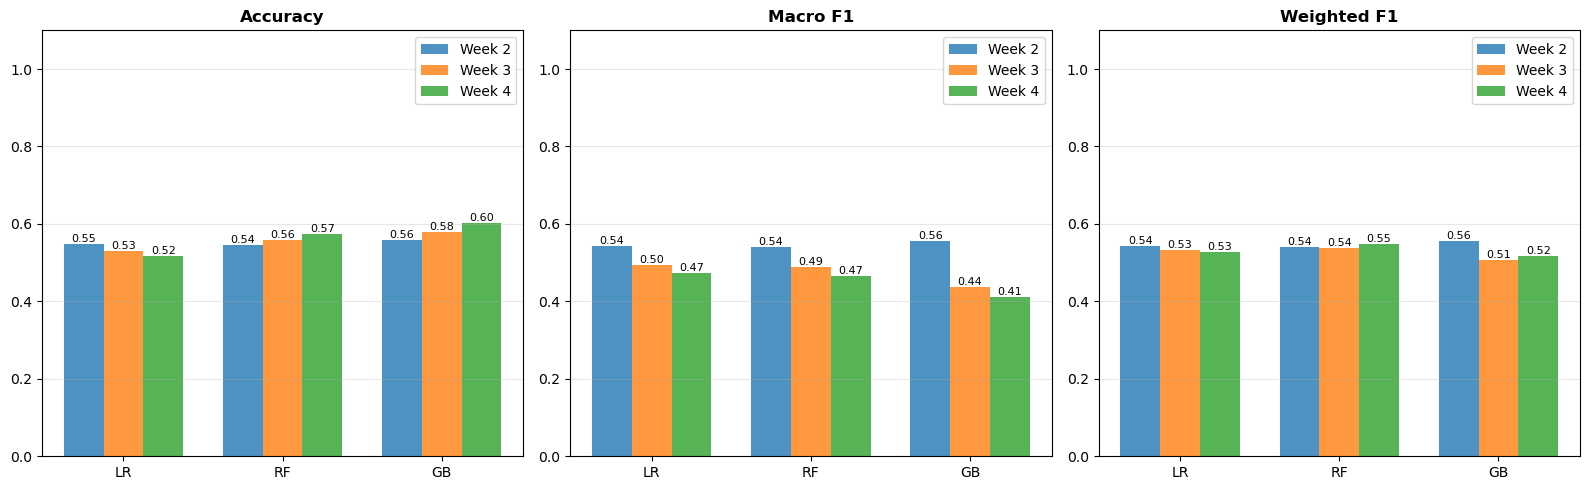

In [15]:
# Try to load unbalanced results for comparison
print('='*70)
print('LOADING UNBALANCED RESULTS FOR COMPARISON')
print('='*70)

try:
    results_week2_unbal = joblib.load("../data/ale_simplicistic_model/model_ready/results_week2.pkl")
    print("✓ Loaded Week 2 unbalanced results")
    has_unbalanced = True
except FileNotFoundError:
    print("⚠️  Unbalanced Week 2 results not found. Run 5-model_second_week.ipynb first.")
    has_unbalanced = False

# Create comparison
all_results_balanced = {
    'Week 2': results_week2_balanced,
    'Week 3': results_week3_balanced,
    'Week 4': results_week4_balanced
}

# Plot balanced results
comparison_df_balanced = plot_multi_week_comparison(
    all_results_balanced, 
    weeks=['Week 2', 'Week 3', 'Week 4']
)

## Side-by-Side Comparison: Balanced vs Unbalanced

Compare Week 2 performance with and without balancing.


WEEK 2 COMPARISON: BALANCED vs UNBALANCED


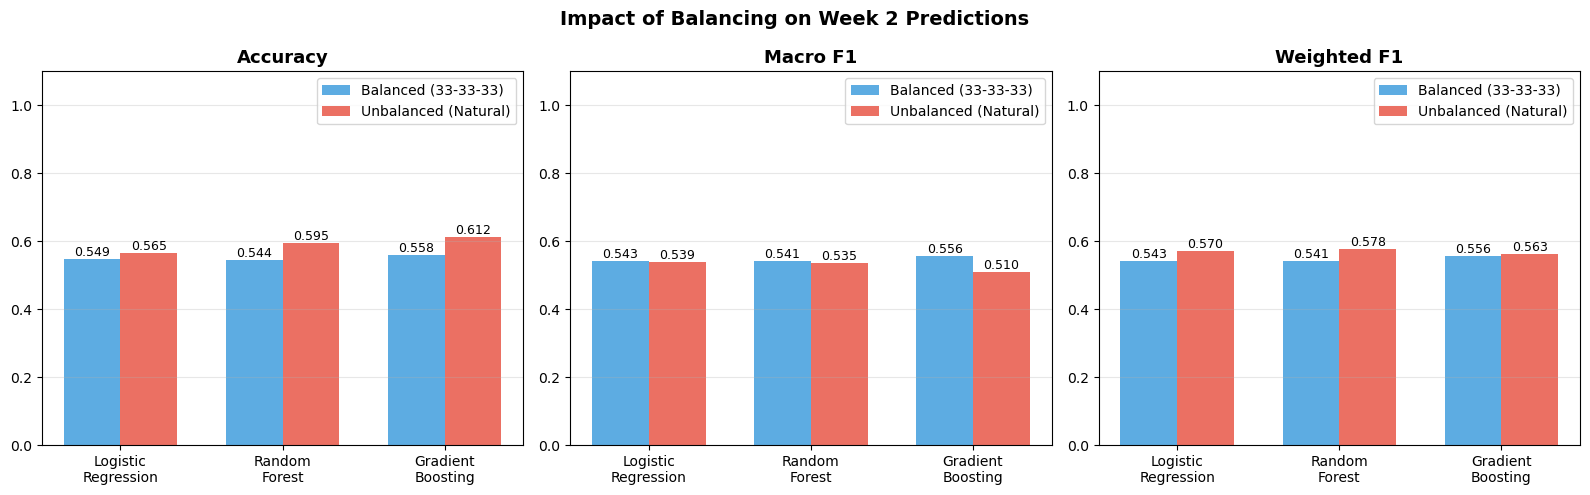


Detailed Comparison:

LogisticRegression:
  Balanced   - Acc: 0.5489, F1 Macro: 0.5428, F1 Weighted: 0.5428
  Unbalanced - Acc: 0.5652, F1 Macro: 0.5387, F1 Weighted: 0.5699
  Difference - Acc: -0.0163, F1 Macro: +0.0041

RandomForest:
  Balanced   - Acc: 0.5444, F1 Macro: 0.5407, F1 Weighted: 0.5407
  Unbalanced - Acc: 0.5949, F1 Macro: 0.5347, F1 Weighted: 0.5775
  Difference - Acc: -0.0504, F1 Macro: +0.0060

GradientBoosting:
  Balanced   - Acc: 0.5584, F1 Macro: 0.5563, F1 Weighted: 0.5563
  Unbalanced - Acc: 0.6121, F1 Macro: 0.5098, F1 Weighted: 0.5630
  Difference - Acc: -0.0537, F1 Macro: +0.0465


In [16]:
# Compare Week 2: Balanced vs Unbalanced
if has_unbalanced:
    import matplotlib.pyplot as plt
    
    print('\n' + '='*70)
    print('WEEK 2 COMPARISON: BALANCED vs UNBALANCED')
    print('='*70)
    
    models = ['LogisticRegression', 'RandomForest', 'GradientBoosting']
    model_names = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']
    
    metrics = ['accuracy', 'f1_macro', 'f1_weighted']
    metric_labels = ['Accuracy', 'Macro F1', 'Weighted F1']
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[idx]
        
        balanced_vals = [results_week2_balanced[m][metric] for m in models]
        unbalanced_vals = [results_week2_unbal[m][metric] for m in models]
        
        x = np.arange(len(models))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, balanced_vals, width, label='Balanced (33-33-33)', alpha=0.8, color='#3498db')
        bars2 = ax.bar(x + width/2, unbalanced_vals, width, label='Unbalanced (Natural)', alpha=0.8, color='#e74c3c')
        
        ax.set_title(f'{label}', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, fontsize=10)
        ax.set_ylim([0, 1.1])
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('Impact of Balancing on Week 2 Predictions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print comparison table
    print('\nDetailed Comparison:')
    for model in models:
        print(f"\n{model}:")
        print(f"  Balanced   - Acc: {results_week2_balanced[model]['accuracy']:.4f}, "
              f"F1 Macro: {results_week2_balanced[model]['f1_macro']:.4f}, "
              f"F1 Weighted: {results_week2_balanced[model]['f1_weighted']:.4f}")
        print(f"  Unbalanced - Acc: {results_week2_unbal[model]['accuracy']:.4f}, "
              f"F1 Macro: {results_week2_unbal[model]['f1_macro']:.4f}, "
              f"F1 Weighted: {results_week2_unbal[model]['f1_weighted']:.4f}")
        
        # Calculate differences
        acc_diff = results_week2_balanced[model]['accuracy'] - results_week2_unbal[model]['accuracy']
        f1_diff = results_week2_balanced[model]['f1_macro'] - results_week2_unbal[model]['f1_macro']
        print(f"  Difference - Acc: {acc_diff:+.4f}, F1 Macro: {f1_diff:+.4f}")
else:
    print("Cannot compare - run 5-model_second_week.ipynb to generate unbalanced results first.")

## Per-Class F1 Analysis: Balanced Data

Examine how well each class is predicted with balanced data.

In [17]:
# Per-class F1 scores for balanced data
print('\n' + '='*80)
print('PER-CLASS F1 SCORES (BALANCED DATA)')
print('='*80)

models = ['LogisticRegression', 'RandomForest', 'GradientBoosting']
model_display = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

for week in ['Week 2', 'Week 3', 'Week 4']:
    print(f'\n{week}:')
    for model_key, model_name in zip(models, model_display):
        print(f"  {model_name}:")
        f1_scores = all_results_balanced[week][model_key]['f1_per_class']
        print(f"    Class 0 (Inactive):  F1 = {f1_scores[0]:.4f}")
        print(f"    Class 1 (Low 1-3):   F1 = {f1_scores[1]:.4f}")
        print(f"    Class 2 (High 4+):   F1 = {f1_scores[2]:.4f}")


PER-CLASS F1 SCORES (BALANCED DATA)

Week 2:
  Logistic Regression:
    Class 0 (Inactive):  F1 = 0.6047
    Class 1 (Low 1-3):   F1 = 0.3894
    Class 2 (High 4+):   F1 = 0.6345
  Random Forest:
    Class 0 (Inactive):  F1 = 0.5974
    Class 1 (Low 1-3):   F1 = 0.3980
    Class 2 (High 4+):   F1 = 0.6269
  Gradient Boosting:
    Class 0 (Inactive):  F1 = 0.6112
    Class 1 (Low 1-3):   F1 = 0.4211
    Class 2 (High 4+):   F1 = 0.6367

Week 3:
  Logistic Regression:
    Class 0 (Inactive):  F1 = 0.6415
    Class 1 (Low 1-3):   F1 = 0.2993
    Class 2 (High 4+):   F1 = 0.5444
  Random Forest:
    Class 0 (Inactive):  F1 = 0.6909
    Class 1 (Low 1-3):   F1 = 0.2354
    Class 2 (High 4+):   F1 = 0.5376
  Gradient Boosting:
    Class 0 (Inactive):  F1 = 0.7087
    Class 1 (Low 1-3):   F1 = 0.0569
    Class 2 (High 4+):   F1 = 0.5455

Week 4:
  Logistic Regression:
    Class 0 (Inactive):  F1 = 0.6423
    Class 1 (Low 1-3):   F1 = 0.2845
    Class 2 (High 4+):   F1 = 0.4907
  Random Fores

## Confusion Matrices: Balanced Data

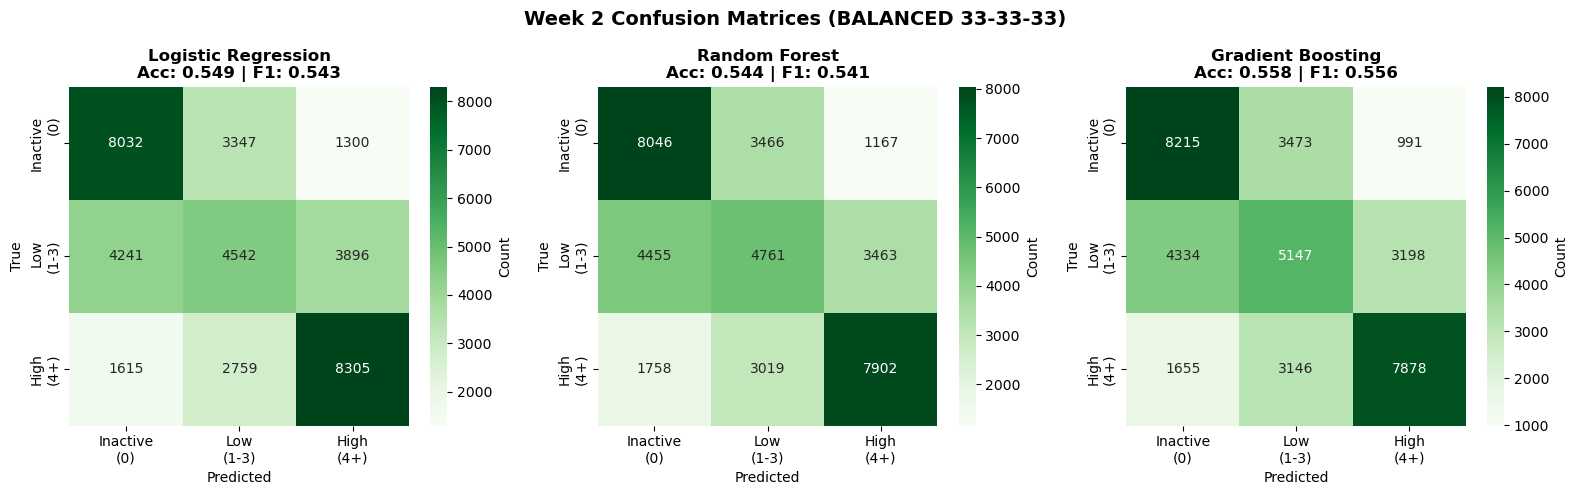

In [ ]:
# Plot confusion matrices for Week 2 only (most interesting comparison)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
class_labels = ['Inactive\n(0)', 'Low\n(1-3)', 'High\n(4+)']

models = ['LogisticRegression', 'RandomForest', 'GradientBoosting']
model_display = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

for idx, (model_key, model_name) in enumerate(zip(models, model_display)):
    ax = axes[idx]
    cm = results_week2_balanced[model_key]['confusion_matrix']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                cbar_kws={'label': 'Count'})
    
    acc = results_week2_balanced[model_key]['accuracy']
    f1 = results_week2_balanced[model_key]['f1_macro']
    
    ax.set_title(f'{model_name}\nAcc: {acc:.3f} | F1: {f1:.3f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

plt.suptitle('Week 2 Confusion Matrices (BALANCED 33-33-33)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
print(results_week2_balanced['GradientBoosting']['confusion_matrix'])
print(results_week2_balanced['GradientBoosting']['f1_macro'])
print(results_week3_balanced['GradientBoosting']['confusion_matrix'])
print(results_week3_balanced['GradientBoosting']['f1_macro'])
print(results_week4_balanced['GradientBoosting']['confusion_matrix'])
print(results_week4_balanced['GradientBoosting']['f1_macro'])

[[8215 3473  991]
 [4334 5147 3198]
 [1655 3146 7878]]
0.5563281608959411
[[16141   227  2216]
 [ 6501   286  2509]
 [ 4328   247  5582]]
0.4370261077648738
[[19203    67  1755]
 [ 6936    72  1663]
 [ 4624    80  3637]]
0.4100862417715514


## Save Balanced Models

In [19]:
# Save balanced models
metadata_week2_bal = save_models(
    results_week2_balanced,
    scaler=data_week2['scaler'],
    feature_cols=list(X.columns),
    week_label="Week 2 Balanced",
    model_dir="../data/ale_simplicistic_model/model_ready/balanced"
)

metadata_week3_bal = save_models(
    results_week3_balanced,
    scaler=data_week3['scaler'],
    feature_cols=list(X.columns),
    week_label="Week 3 Balanced",
    model_dir="../data/ale_simplicistic_model/model_ready/balanced"
)

metadata_week4_bal = save_models(
    results_week4_balanced,
    scaler=data_week4['scaler'],
    feature_cols=list(X.columns),
    week_label="Week 4 Balanced",
    model_dir="../data/ale_simplicistic_model/model_ready/balanced"
)

print("\n✓ All balanced models saved successfully!")


SAVING MODELS - Week 2 Balanced
✓ LogisticRegression saved: ../data/ale_simplicistic_model/model_ready/balanced/logisticregression_week2balanced_20260128_124913.pkl
✓ RandomForest saved: ../data/ale_simplicistic_model/model_ready/balanced/randomforest_week2balanced_20260128_124913.pkl
✓ GradientBoosting saved: ../data/ale_simplicistic_model/model_ready/balanced/gradientboosting_week2balanced_20260128_124913.pkl
✓ Scaler saved: ../data/ale_simplicistic_model/model_ready/balanced/scaler_week2balanced_20260128_124913.pkl
✓ Metadata saved: ../data/ale_simplicistic_model/model_ready/balanced/metadata_week2balanced_20260128_124913.pkl

SAVING MODELS - Week 3 Balanced
✓ LogisticRegression saved: ../data/ale_simplicistic_model/model_ready/balanced/logisticregression_week3balanced_20260128_124913.pkl
✓ RandomForest saved: ../data/ale_simplicistic_model/model_ready/balanced/randomforest_week3balanced_20260128_124913.pkl
✓ GradientBoosting saved: ../data/ale_simplicistic_model/model_ready/balanc

## Key Insights

**Expected Observations:**

1. **Macro F1 Score**: Should be higher with balanced data, as all classes are equally represented
2. **Weighted F1 Score**: Might be lower with balanced data, as we're optimizing for rare classes
3. **Minority Class Performance**: Should improve significantly with balancing
4. **Overall Accuracy**: May decrease slightly as we're not just predicting the majority class

**Trade-offs:**
- Balanced data: Better at catching rare blocking behavior (high activity)
- Unbalanced data: Better overall accuracy but may miss rare events
- Choice depends on use case: Are false negatives or false positives more costly?